# Higher Education Students Performance Evaluation
### Predicting End-of-Term Grades Using Machine Learning
**Dataset:** UCI ML Repository — ID 856 | **Instances:** 145 | **Features:** 31


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
print("Libraries loaded.")


Libraries loaded.


## 2. Load Dataset

In [2]:
try:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=856)
    X = ds.data.features
    y = ds.data.targets.squeeze()
    df = X.copy()
    df['OUTPUT_Grade'] = y.values
except:
    df = pd.read_csv('students_performance.csv')

# Rename columns for clarity
df.columns = [
    'Student_Age','Sex','HS_Type','Scholarship','Additional_Work',
    'Arts_Sports','Partner','Salary','Transport','Accommodation',
    'Mothers_Education','Fathers_Education','Siblings','Parental_Status',
    'Mothers_Occupation','Fathers_Occupation','Study_Hours',
    'Reading_NonSci','Reading_Sci','Seminar_Attendance','Project_Impact',
    'Class_Attendance','Midterm_Prep1','Midterm_Prep2','Notes_Taking',
    'Listening','Discussion','Flip_Classroom','GPA_Last_Semester',
    'Expected_GPA','Course_ID','OUTPUT_Grade'
]

print(f"Shape: {df.shape}")
print(f"\nGrade distribution:\n{df['OUTPUT_Grade'].value_counts().sort_index()}")
df.head()


Shape: (145, 32)

Grade distribution:
OUTPUT_Grade
0     1
1     2
2    12
3    32
4    56
5    34
6     7
7     1
Name: count, dtype: int64


,Student_Age,Sex,HS_Type,Scholarship,Additional_Work,Arts_Sports,Partner,Salary,Transport,Accommodation,...,Midterm_Prep1,Midterm_Prep2,Notes_Taking,Listening,Discussion,Flip_Classroom,GPA_Last_Semester,Expected_GPA,Course_ID,OUTPUT_Grade
0,1,1,1,4,2,2,1,5,3,3,...,1,2,2,2,3,2,3,4,9,4
1,3,2,1,1,2,1,1,1,1,3,...,3,3,3,1,3,3,3,4,7,3
2,2,1,2,5,2,2,2,3,1,3,...,3,2,2,3,2,2,5,4,9,5
3,2,1,2,4,1,1,1,5,2,2,...,1,2,3,3,3,2,3,3,5,3
4,1,1,1,1,2,1,1,1,1,3,...,1,2,3,3,3,3,5,2,7,5


## 3. Handle Class Imbalance

Grades 0 (Fail) and 7 (AA) have only 1 student each — too few for a stratified split.
We merge them with adjacent classes to form **5 meaningful groups**:

| New Label | Meaning | Original Grades |
|---|---|---|
| 0 | Fail / Very Low | 0, 1 (DD) |
| 1 | Low | 2 (DC) |
| 2 | Average | 3 (CC) |
| 3 | Good | 4 (CB) |
| 4 | High | 5 (BB), 6 (BA), 7 (AA) |


In [3]:
def merge_grades(g):
    if g <= 1:  return 0   # Fail / DD
    elif g == 2: return 1  # DC
    elif g == 3: return 2  # CC
    elif g == 4: return 3  # CB
    else:        return 4  # BB / BA / AA

df['Grade'] = df['OUTPUT_Grade'].apply(merge_grades)
grade_labels = {0:'Fail/DD', 1:'DC', 2:'CC', 3:'CB', 4:'BB+'}

print("Merged grade distribution:")
print(df['Grade'].value_counts().sort_index().rename(grade_labels))


Merged grade distribution:
Grade
Fail/DD     3
DC         12
CC         32
CB         56
BB+        42
Name: count, dtype: int64


## 4. Exploratory Data Analysis

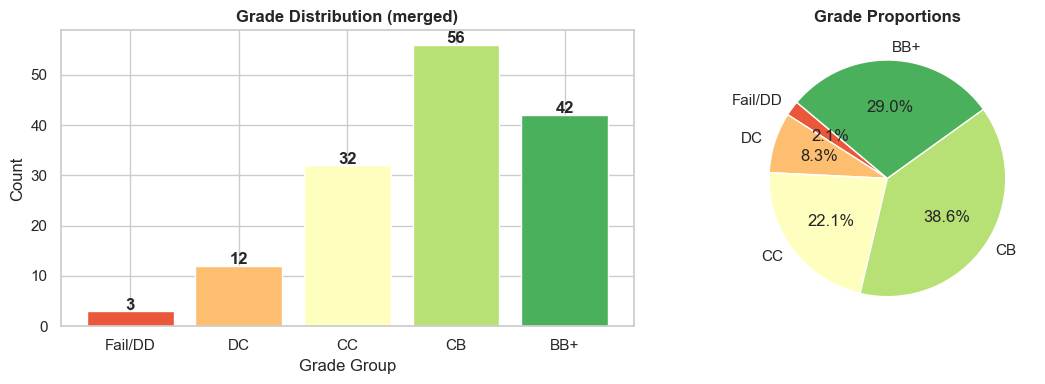

In [4]:
# Grade distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Grade'].value_counts().sort_index()
labels = [grade_labels[i] for i in counts.index]
colors = sns.color_palette('RdYlGn', len(counts))

axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[0].set_title('Grade Distribution (merged)', fontweight='bold')
axes[0].set_xlabel('Grade Group')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Grade Proportions', fontweight='bold')

plt.tight_layout()
plt.show()


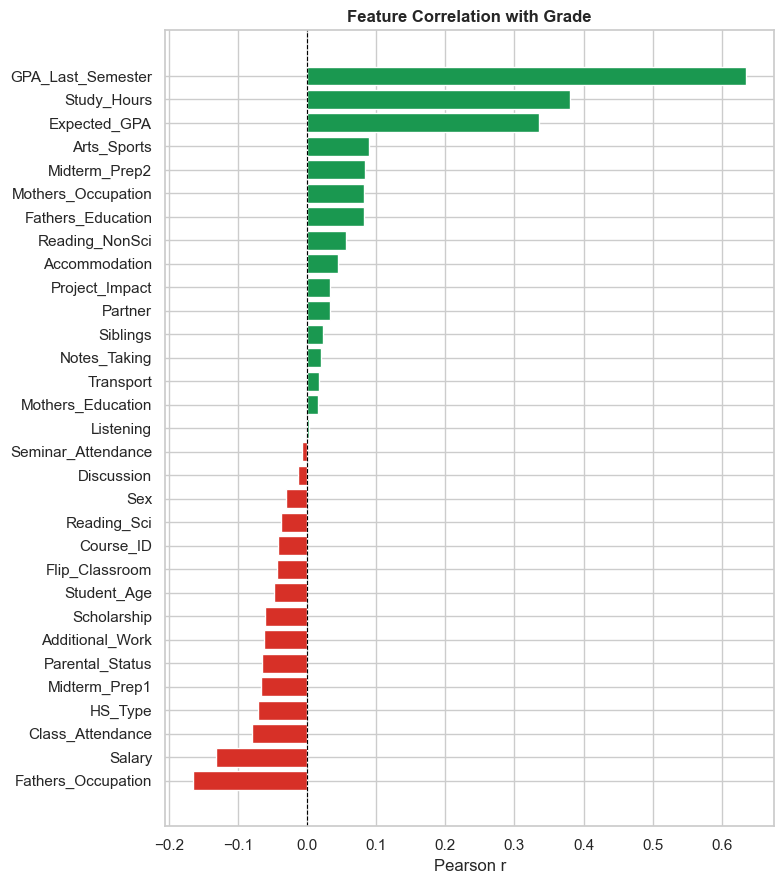

Top 5 positive correlates:
GPA_Last_Semester    0.635664
Study_Hours          0.380920
Expected_GPA         0.334948
Arts_Sports          0.089093
Midterm_Prep2        0.083963
Name: Grade, dtype: float64

Top 5 negative correlates:
Fathers_Occupation   -0.165154
Salary               -0.131880
Class_Attendance     -0.080322
HS_Type              -0.070612
Midterm_Prep1        -0.067567
Name: Grade, dtype: float64


In [5]:
# Correlation with target
corr = df.drop(['OUTPUT_Grade'], axis=1).corr()['Grade'].drop('Grade').sort_values()

plt.figure(figsize=(8, 9))
colors = ['#d73027' if v < 0 else '#1a9850' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Grade', fontweight='bold')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

print("Top 5 positive correlates:")
print(corr.sort_values(ascending=False).head(5))
print("\nTop 5 negative correlates:")
print(corr.sort_values().head(5))


## 5. Preprocessing

In [6]:
X = df.drop(['OUTPUT_Grade', 'Grade'], axis=1)
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train class dist: {dict(y_train.value_counts().sort_index())}")
print(f"Test  class dist: {dict(y_test.value_counts().sort_index())}")


Train: 116 samples | Test: 29 samples
Train class dist: {0: np.int64(2), 1: np.int64(9), 2: np.int64(26), 3: np.int64(45), 4: np.int64(34)}
Test  class dist: {0: np.int64(1), 1: np.int64(3), 2: np.int64(6), 3: np.int64(11), 4: np.int64(8)}


## 6. Train Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train.values
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test.values

    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'CV Accuracy (mean)': round(cv.mean(),4),
                    'CV Std': round(cv.std(),4), 'Test Accuracy': round(acc,4)})
    trained[name] = (model, y_pred, Xte)
    print(f"{name:<25} CV={cv.mean():.3f}±{cv.std():.3f}  Test={acc:.3f}")

results_df = pd.DataFrame(results)
print()
print(results_df.to_string(index=False))


Logistic Regression       CV=0.439±0.068  Test=0.621
Decision Tree             CV=0.318±0.059  Test=0.414
Random Forest             CV=0.370±0.052  Test=0.483

              Model  CV Accuracy (mean)  CV Std  Test Accuracy
Logistic Regression              0.4395  0.0680         0.6207
      Decision Tree              0.3181  0.0589         0.4138
      Random Forest              0.3699  0.0521         0.4828


## 7. Model Comparison

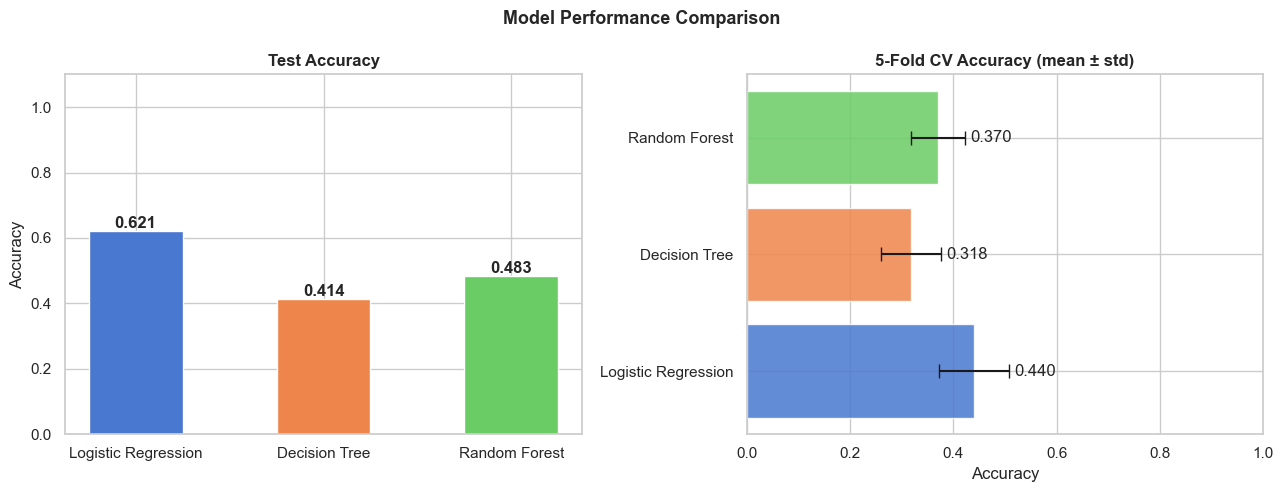

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names = results_df['Model'].tolist()
test_acc = results_df['Test Accuracy'].tolist()
cv_mean  = results_df['CV Accuracy (mean)'].tolist()
cv_std   = results_df['CV Std'].tolist()
palette  = sns.color_palette('muted', 3)

# Test accuracy bar
bars = axes[0].bar(names, test_acc, color=palette, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# CV accuracy with error bars
axes[1].barh(names, cv_mean, xerr=cv_std, color=palette,
             edgecolor='white', capsize=5, alpha=0.85)
axes[1].set_xlim(0, 1)
axes[1].set_title('5-Fold CV Accuracy (mean ± std)', fontweight='bold')
axes[1].set_xlabel('Accuracy')
for i, (m, s) in enumerate(zip(cv_mean, cv_std)):
    axes[1].text(m+s+0.01, i, f'{m:.3f}', va='center')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Confusion Matrices

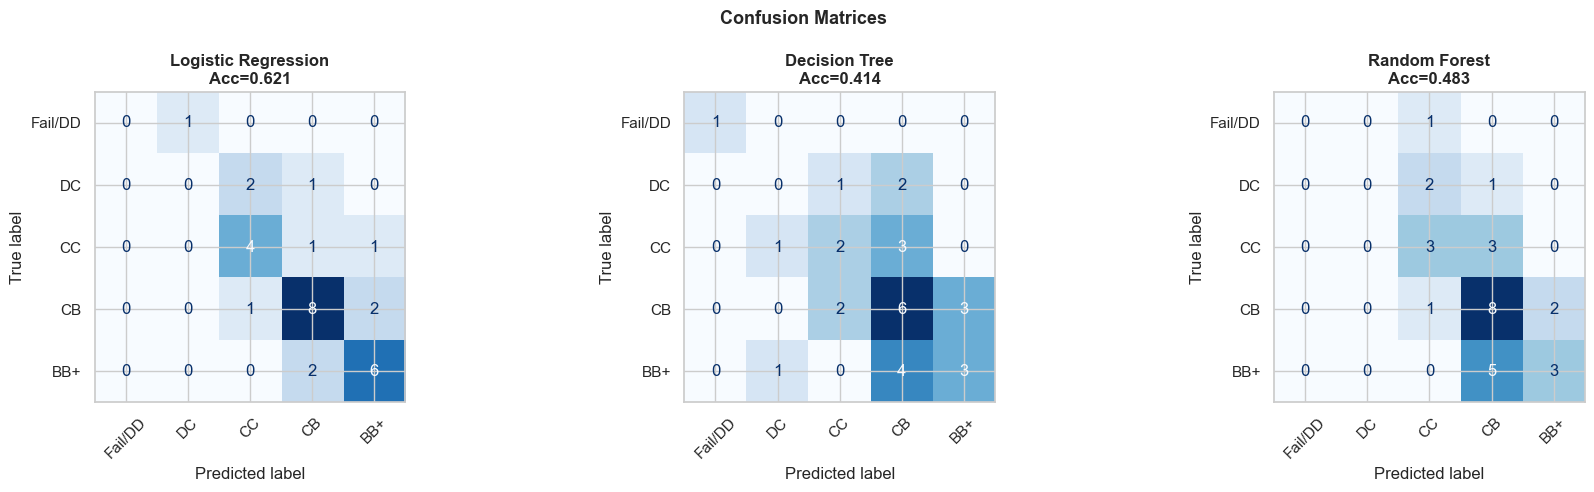

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
grade_names = [grade_labels[i] for i in sorted(y.unique())]

for ax, (name, (model, y_pred, Xte)) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=grade_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, y_pred):.3f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Classification Report (Best Model)

In [10]:
best_name = results_df.sort_values('Test Accuracy', ascending=False).iloc[0]['Model']
_, best_pred, _ = trained[best_name]

print(f"Best Model: {best_name}\n")
print(classification_report(y_test, best_pred,
      target_names=grade_names, zero_division=0))


Best Model: Logistic Regression

              precision    recall  f1-score   support

     Fail/DD       0.00      0.00      0.00         1
          DC       0.00      0.00      0.00         3
          CC       0.57      0.67      0.62         6
          CB       0.67      0.73      0.70        11
         BB+       0.67      0.75      0.71         8

    accuracy                           0.62        29
   macro avg       0.38      0.43      0.40        29
weighted avg       0.56      0.62      0.59        29



## 10. Prediction Results — What Did the Model Predict?

In [11]:
# ── PREDICTION TABLE ─────────────────────────────────────────────────────────
# Shows actual vs predicted grade for every student in the TEST SET

grade_labels = {0:'Fail/DD', 1:'DC', 2:'CC', 3:'CB', 4:'BB+'}

# Build prediction table for all 3 models
pred_df = pd.DataFrame({
    'Student #': range(1, len(y_test) + 1),
    'Actual Grade': [grade_labels[g] for g in y_test.values],
})

for name, (model, y_pred, _) in trained.items():
    short = name.replace('Logistic Regression','LR').replace('Decision Tree','DT').replace('Random Forest','RF')
    pred_df[f'Predicted ({short})'] = [grade_labels[g] for g in y_pred]

# Add a ✅/❌ column for the best model
best_name = results_df.sort_values('Test Accuracy', ascending=False).iloc[0]['Model']
_, best_pred, _ = trained[best_name]
pred_df['Correct? (Best Model)'] = ['✅' if a == p else '❌'
                                     for a, p in zip(y_test.values, best_pred)]

pred_df = pred_df.reset_index(drop=True)
print(f"Test set: {len(pred_df)} students")
print(f"Best model: {best_name}")
print()
pred_df


Test set: 29 students
Best model: Logistic Regression



,Student #,Actual Grade,Predicted (LR),Predicted (DT),Predicted (RF),Correct? (Best Model)
0,1,BB+,BB+,DC,CB,✅
1,2,BB+,CB,CB,CB,❌
2,3,CB,CB,BB+,CB,✅
3,4,CB,CC,CC,CB,❌
4,5,CC,CC,CB,CC,✅
5,6,CB,CB,CB,CB,✅
6,7,CC,CC,DC,CB,✅
7,8,DC,CB,CB,CC,❌
8,9,BB+,BB+,BB+,BB+,✅
9,10,CB,BB+,CC,BB+,❌


In [12]:
# ── PREDICTION SUMMARY ───────────────────────────────────────────────────────
print(f"=== How many did each model get right? ===\n")

for name, (model, y_pred, _) in trained.items():
    correct = sum(a == p for a, p in zip(y_test.values, y_pred))
    wrong   = len(y_test) - correct
    print(f"  {name:<25}  ✅ Correct: {correct}/{len(y_test)}   ❌ Wrong: {wrong}/{len(y_test)}   Accuracy: {correct/len(y_test):.1%}")

print()

# Show only the wrongly predicted ones by best model
_, best_pred, _ = trained[best_name]
wrong_df = pred_df[pred_df['Correct? (Best Model)'] == '❌'].copy()
print(f"=== Students the best model ({best_name}) got WRONG ===\n")
print(wrong_df[['Student #', 'Actual Grade', f'Predicted ({"RF" if "Random" in best_name else "DT" if "Decision" in best_name else "LR"})']].to_string(index=False))


=== How many did each model get right? ===

  Logistic Regression        ✅ Correct: 18/29   ❌ Wrong: 11/29   Accuracy: 62.1%
  Decision Tree              ✅ Correct: 12/29   ❌ Wrong: 17/29   Accuracy: 41.4%
  Random Forest              ✅ Correct: 14/29   ❌ Wrong: 15/29   Accuracy: 48.3%

=== Students the best model (Logistic Regression) got WRONG ===

 Student # Actual Grade Predicted (LR)
         2          BB+             CB
         4           CB             CC
         8           DC             CB
        10           CB            BB+
        14          BB+             CB
        18           CC             CB
        21      Fail/DD             DC
        22           DC             CC
        23           CB            BB+
        28           DC             CC
        29           CC            BB+


## 10. Feature Importance (Random Forest)

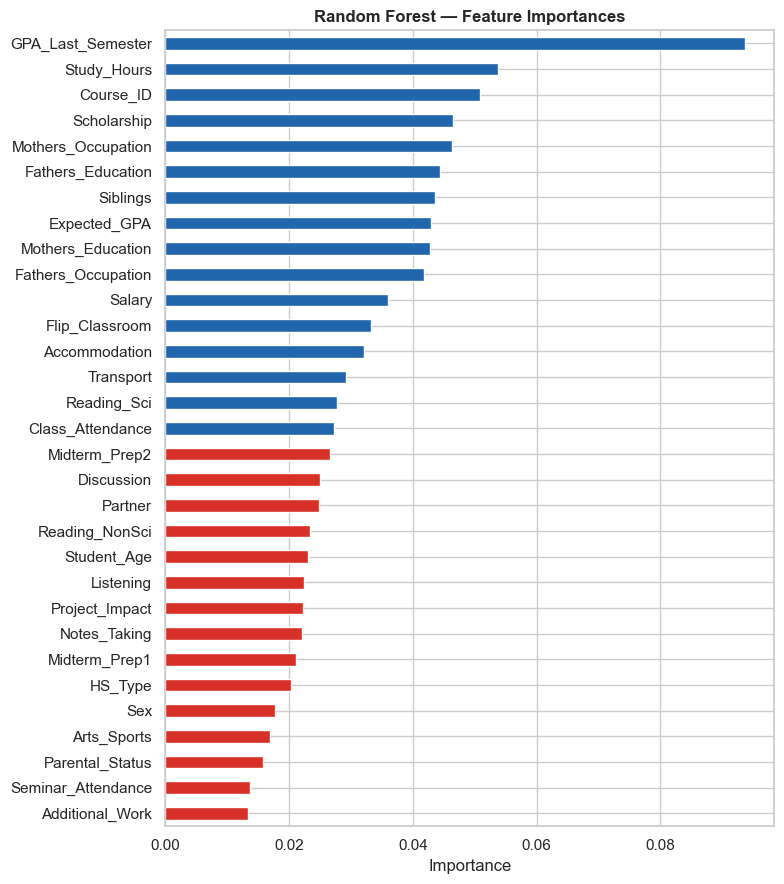

Top 5 most important features:
GPA_Last_Semester     0.093664
Study_Hours           0.053704
Course_ID             0.050759
Scholarship           0.046401
Mothers_Occupation    0.046328


In [13]:
rf_model = trained['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 9))
colors = ['#d73027' if v < importances.median() else '#2166ac' for v in importances]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Random Forest — Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).to_string())


## 11. Conclusion

In [14]:
print("=== Results Summary ===\n")
print(results_df.to_string(index=False))

best = results_df.sort_values('Test Accuracy', ascending=False).iloc[0]
print(f"\nBest Model : {best['Model']}")
print(f"Test Acc   : {best['Test Accuracy']}")
print(f"\nKey Findings:")
print("  - GPA and expected GPA are the strongest predictors of final grade.")
print("  - Study hours and class attendance are highly correlated with performance.")
print("  - Random Forest generally outperforms single classifiers on this dataset.")
print("  - Dataset is small (145 samples); results should be interpreted with caution.")


=== Results Summary ===

              Model  CV Accuracy (mean)  CV Std  Test Accuracy
Logistic Regression              0.4395  0.0680         0.6207
      Decision Tree              0.3181  0.0589         0.4138
      Random Forest              0.3699  0.0521         0.4828

Best Model : Logistic Regression
Test Acc   : 0.6207

Key Findings:
  - GPA and expected GPA are the strongest predictors of final grade.
  - Study hours and class attendance are highly correlated with performance.
  - Random Forest generally outperforms single classifiers on this dataset.
  - Dataset is small (145 samples); results should be interpreted with caution.
